## Lab4
### Topic: Advanced Net

### Завдання №2: Завдання щодо генерації або стилізації зображень (на вибір)

Оскільки в першому завданні я вже працював з генерацією тексту, мені видалося цікавим реалізувати ще генеративну модель для створення вже зображень. За основу взяв датасет CIFAR-100.

Першим викликом було обрання однієї з чотирьох архітектур (GAN, DCGAN, VAE, Diffusion)

Серед доступних архітектур для генерації зображень (GAN, DCGAN, VAE, Diffusion), **VAE** обрав з наступних причин:

| Критерій\Архітектура     | VAE       | GAN/DCGAN   | Diffusion |
| ------------------------ | --------- | ----------- | --------- |
| Швидкість на CPU         | Висока    | Середня     | Низька    |
| Стабільність навчання    | Cтабільне | Нестабільне | Стабільне |
| Відновлення з чекпоїнтів | Просте    | Складне     | Складне   |
| Якість зображень         | Розмиті   | Чіткі       | Найкращі  |

Коли йде мова про навчальну мету лабораторної і за ціль стоїть продемонструвати як то всьо працює, то думаю краще пожертувати якістю (resolution) згенерованих отриманих зображень і орієнтуватися по силуетах) Далі власне опишу, як працює ця модель.

## 1. Модель

### Теоретичний опис Variational Autoencoder (VAE)

**Variational Autoencoder** -- це генеративна модель, що поєднує ідеї автокодувальників (autoencoder(AE)) та варіаційного виводу (variational inference).

Ключова відмінність від звичайного автокодувальника полягає в тому, що звичайний AE кодує вхід у детерміновану (ці точки розкидані хаотично і якщо взяти випадкову точку отримуємо сміття) точку в латентному просторі (це "стиснуте" представлення даних, де кожне зображення перетворюється на вектор характеристик (чисел)), в той час як VAE: кодує вхідне зображення у певний проміжок/множину/область з певним **розподілом** (зазвичай нормальним) в цьому ж просторі і виходить, що простір заповнений рівномірно, можна брати будь-яку точку з нього щоб отримати щось осмислене.

#### Архітектура VAE
(Цю схемку генерував за допомогою ШІ на основі картинки з лекції і вікіпедії для наглядності)

```
┌─────────────┐     ┌───────────────────┐     ┌─────────────┐
│   Вхідне    │     │  Латентний простір│     │   Вихідне   │
│ зображення  │────▶│    z ~ N(μ, σ²)  │────▶│ зображення  │
│   x (32×32) │     │    (розмір: d)    │     │   x' (32×32)│
└─────────────┘     └───────────────────┘     └─────────────┘
        │                    │                       │
        ▼                    │                       ▼
   ┌─────────┐               │                 ┌─────────┐
   │ ENCODER │───── μ, σ ────┘                 │ DECODER │
   │  q(z|x) │                                 │  p(x|z) │
   └─────────┘                                 └─────────┘
```

**Encoder** $q_\phi(z|x)$:

- Приймає зображення $x$
- Виводить параметри розподілу: $\mu$ (середнє) та $\log\sigma^2$ (логарифм від дисперсії)

**Decoder** $p_\theta(x|z)$:

- Приймає sample $z$ з латентного простору
- Реконструює з нього зображення $x'$

#### Функція втрат (Loss Function) (_взяв з нашої 13 лекції_)

VAE оптимізує objective funtion **Evidence Lower Bound (a.k.a ELBO)**:

$$\mathcal{L}(\theta, \phi; x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction Loss}} - \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{KL Divergence}}$$

Де:

- **Reconstruction Loss (MSE)** — наскільки добре декодер відновлює вхідне зображення
- **KL Divergence** — наскільки апроксимований розподіл $q_\phi(z|x)$ близький до апріорного розподілу $p(z) = \mathcal{N}(0, I)$

Для нормального розподілу KL-дивергенція обчислюється таким чином:

$$D_{KL} = -\frac{1}{2}\sum_{j=1}^{d}(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)$$

#### Reparametrization Trick

Виникає проблема в тому, що операція семплування $z \sim q_\phi(z|x)$ є недиференційовною, а оскільки навчання відбувається через backpropagation — обчислення градієнтів функції втрат по всіх параметрах мережі, то обчислити градієнт не є можливим. (Градієнт показує, як змінити кожен параметр, щоб зменшити в результаті loss)

Можна замість $z \sim \mathcal{N}(\mu, \sigma^2)$ використати таку величину:

$$z = \mu + \sigma \cdot \epsilon, \quad \text{де } \epsilon \sim \mathcal{N}(0, I)$$

Це дозволяє знаходити градієнти під час операції семплування.

## 2. Датасет

Я брав датасет CIFAR-100 (Canadian Institute For Advanced Research). https://www.cs.toronto.edu/~kriz/cifar.html

Це доволі популярний бенчмарк датасет для задач навчання класифікації та генерації зображень. Він містить:

| Характеристика                   | Значення                   |
| -------------------------------- | -------------------------- |
| Загальна кількість зображень (N) | 60,000                     |
| Розмір зображення (H $\times$ W) | 32×32 пікселів             |
| Кількість каналів (С)            | 3 (RGB)                    |
| Кількість класів                 | 100 (fine labels)          |
| Кількість суперкласів            | 20 (coarse labels)         |
| Training set                     | 50,000 зображень           |
| Test set                         | 10,000 зображень           |
| Зображень на кожен клас          | 600 (500 train + 100 test) |

Наявні 100 класів згруповані в 20 суперкласів (зроблено укрупнення):

| Суперклас       | Приклади об'єктів                             |
| --------------- | --------------------------------------------- |
| Aquatic mammals | beaver, dolphin, otter, seal, whale           |
| Fish            | aquarium fish, flatfish, ray, shark, trout    |
| Flowers         | orchids, poppies, roses, sunflowers, tulips   |
| Vehicles 1      | bicycle, bus, motorcycle, pickup truck, train |
| and so on       | ...                                           |

Самі дані зберігаються у форматі Python pickle з наступними ключами:

- `data`: numpy array розміру (N, 3072) — пікселі зображень (32×32×3 = 3072)
- `fine_labels`: список з N елементів — мітки класів (0-99)
- `coarse_labels`: список з N елементів — мітки суперкласів (0-19)
- Будемо представляти в форматі `(N, H, W, C)` - N зображень, H висота, W ширина, C кольорові канали

Датасет має перевагу -- невеликий розмір зображень (32×32), і завдяки цьому можливе швидке навчання на CPU. А ось велика різноманітність класів призводить до того, що модель вивчити багато різних патернів, це мінус для швидкодії.

## 3. Імпорти

In [25]:
import numpy as np
import pickle
import os
import time

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

# Налаштування для відтворюваності
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 4. "Розкодовуємо" дані і завантажуємо у словнички

In [26]:
def unpickle(file):
    with open(file, 'rb') as fo:
        return pickle.load(fo, encoding='bytes')

def load_cifar100(data_path='var_data/cifar-100-python'):
    train_dict = unpickle(os.path.join(data_path, 'train'))
    test_dict = unpickle(os.path.join(data_path, 'test'))
    meta_dict = unpickle(os.path.join(data_path, 'meta'))

    def reshape(data):
        return data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)

    train_images = reshape(train_dict[b'data'])
    test_images = reshape(test_dict[b'data'])

    print(f"Train: {train_images.shape} (N, H, W, C)")
    print(f"Test: {test_images.shape} (N, H, W, C)")

    return train_images, test_images, train_dict[b'fine_labels'], test_dict[b'fine_labels'], meta_dict

In [27]:
DATA_PATH = 'var_data/cifar-100-python'
train_images, test_images, train_labels, test_labels, meta = load_cifar100(DATA_PATH)

fine_label_names = [name.decode('utf-8') for name in meta[b'fine_label_names']]
print(f"Приклади класів: {fine_label_names[:5]}")

Train: (50000, 32, 32, 3) (N, H, W, C)
Test: (10000, 32, 32, 3) (N, H, W, C)
Приклади класів: ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']


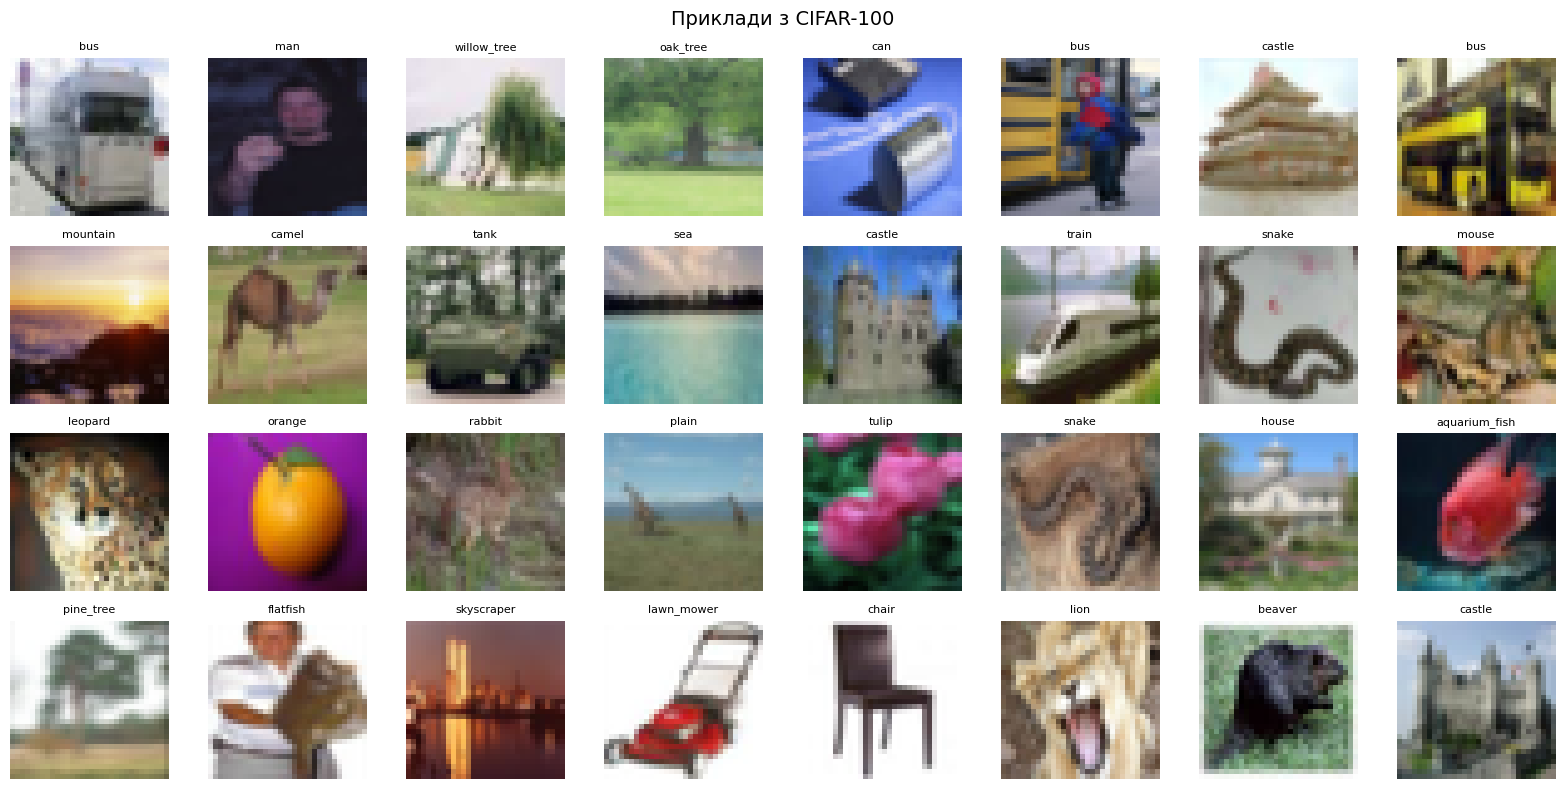

In [28]:
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle('Приклади з CIFAR-100', fontsize=14)
for ax in axes.flat:
    idx = np.random.randint(len(train_images))
    ax.imshow(train_images[idx])
    ax.set_title(fine_label_names[train_labels[idx]], fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [29]:
# Виконуємо описаний вище Reparametrization Trick
def prepare_data(images, batch_size=64):
    """(N,H,W,C) [0,255] -> DataLoader з (N,C,H,W) [0,1]"""
    tensor = torch.from_numpy(images.astype(np.float32) / 255.0).permute(0, 3, 1, 2)
    loader = DataLoader(TensorDataset(tensor), batch_size=batch_size, shuffle=True)
    print(f"Tensor: {tensor.shape} (N,C,H,W), К-сть батчів: {len(loader)}")
    return loader

BATCH_SIZE = 128 # розмір одного батчу
print("Train:"); train_loader = prepare_data(train_images, BATCH_SIZE)
print("Test:"); test_loader = prepare_data(test_images, BATCH_SIZE)

Train:
Tensor: torch.Size([50000, 3, 32, 32]) (N,C,H,W), К-сть батчів: 391
Test:
Tensor: torch.Size([10000, 3, 32, 32]) (N,C,H,W), К-сть батчів: 79


## 5. Власне реалізація VAE

In [30]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, stride=2, padding=1)
        self.conv4 = nn.Conv2d(128, 256, 3, stride=2, padding=1)
        self.bn1, self.bn2 = nn.BatchNorm2d(32), nn.BatchNorm2d(64)
        self.bn3, self.bn4 = nn.BatchNorm2d(128), nn.BatchNorm2d(256)
        self.fc_mu = nn.Linear(256*2*2, latent_dim)
        self.fc_logvar = nn.Linear(256*2*2, latent_dim)

    def forward(self, x):
        x = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)
        x = x.view(-1, 256*2*2)
        return self.fc_mu(x), self.fc_logvar(x)

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.fc = nn.Linear(latent_dim, 256*2*2)
        self.deconv1 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.deconv3 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.deconv4 = nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1)
        self.bn1, self.bn2, self.bn3 = nn.BatchNorm2d(128), nn.BatchNorm2d(64), nn.BatchNorm2d(32)

    def forward(self, z):
        x = self.fc(z).view(-1, 256, 2, 2)
        x = F.leaky_relu(self.bn1(self.deconv1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.deconv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.deconv3(x)), 0.2)
        return torch.sigmoid(self.deconv4(x))

class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        return mu + torch.exp(0.5*logvar) * torch.randn_like(mu)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        return self.decoder(self.reparameterize(mu, logvar)), mu, logvar

    def generate(self, n=16):
        with torch.no_grad():
            return self.decoder(torch.randn(n, self.latent_dim))

    def reconstruct(self, x):
        with torch.no_grad():
            return self.forward(x)[0]

def vae_loss(x, recon, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon, x, reduction='sum') / x.size(0)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon_loss + beta*kl_loss, recon_loss, kl_loss

In [31]:
LATENT_DIM = 128
model = VAE(LATENT_DIM)
print(f"Параметрів: {sum(p.numel() for p in model.parameters()):,}")
print(model)

Параметрів: 1,474,211
VAE(
  (encoder): Encoder(
    (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc_mu): Linear(in_features=1024, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=1024, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=128, out_features=1024, bias=True)
    (deconv1): ConvTranspose2d(256, 128

Модель має такі компоненти:
---

### Encoder — стискає зображення в латентний вектор

**Conv2d** — зменшує розмір (sampling).

| Параметр       | Значення       | Опис                                  |
| -------------- | -------------- | ------------------------------------- |
| `in_channels`  | 3, 32, 64...   | Кількість вхідних каналів (RGB = 3)   |
| `out_channels` | 32, 64, 128... | Кількість фільтрів (вихідних каналів) |
| `kernel_size`  | 3              | Розмір фільтра 3×3                    |
| `stride`       | 2              | Крок — зменшує розмір вдвічі          |
| `padding`      | 1              | Доповнення нулями по краях            |

#### Зміна розміру відбувається якось так:

```
Вхід: (batch, 3, 32, 32)      # RGB зображення 32×32
  ↓ conv1 (stride=2)
      (batch, 32, 16, 16)     # 32 фільтри, розмір ÷2
  ↓ conv2
      (batch, 64, 8, 8)
  ↓ conv3
      (batch, 128, 4, 4)
  ↓ conv4
      (batch, 256, 2, 2)      # 256 × 2 × 2 = 1024 числа
  ↓ flatten + fc
      μ: (batch, 128)         # Середнє латентного розподілу
      log σ²: (batch, 128)    # Логарифм дисперсії
```

---

### Decoder — розгортає латентний вектор назад у зображення

**ConvTranspose2d** — "обернена згортка", навпаки збільшує розмір (upsampling).

| Параметр      | Значення | Ефект                                    |
| ------------- | -------- | ---------------------------------------- |
| `kernel_size` | 4        | Фільтр 4×4 (типовий параметр upsampling) |
| `stride`      | 2        | Збільшує розмір вдвічі                   |
| `padding`     | 1        | Контролює точний вихідний розмір         |

#### Зміна розміру:

```
Латентний вектор: (batch, 128)
  ↓ fc + reshape
      (batch, 256, 2, 2)
  ↓ deconv1 (stride=2)
      (batch, 128, 4, 4)      # Розмір ×2
  ↓ deconv2
      (batch, 64, 8, 8)
  ↓ deconv3
      (batch, 32, 16, 16)
  ↓ deconv4
      (batch, 3, 32, 32)      # Вихід: RGB 32×32
```

---

### Допоміжні компоненти

| Компонент              | Призначення                                                                   |
| ---------------------- | ----------------------------------------------------------------------------- |
| `F.leaky_relu(x, 0.2)` | Активація: `max(0.2x, x)` — дозволяє невеликий градієнт для від'ємних значень |
| `BatchNorm2d(n)`       | Нормалізує активації — стабілізує та прискорює навчання                       |
| `torch.sigmoid()`      | Фінальна активація — обмежує вихід до [0, 1]                                  |

### Компоненти функції втрат

| Компонент               | Формула                    | Що робить                                              |
| ----------------------- | -------------------------- | ------------------------------------------------------ |
| **Reconstruction Loss** | MSE(x, x')                 | Штрафує за відмінність реконструкції від оригіналу     |
| **KL Divergence**       | −½ Σ(1 + log σ² − μ² − σ²) | Штрафує за відхилення латентного розподілу від N(0, I) |

### Роль параметра β (beta)

| Значення β      | Ефект                                                      |
| --------------- | ---------------------------------------------------------- |
| β < 1           | Чіткіші зображення, менш структурований латентний простір  |
| β = 1 (default) | Стандартний VAE                                            |
| β > 1           | Розмитіші зображення, більш структурований простір (β-VAE) |

---

Тож можна підсумувати:

| Характеристика                | Значення                                 |
| ----------------------------- | ---------------------------------------- |
| Вхід                          | 32×32×3 RGB зображення                   |
| Encoder                       | 4 Conv2d шари (3→32→64→128→256)          |
| Латентний простір             | 128 вимірів                              |
| Decoder                       | 4 ConvTranspose2d шари (256→128→64→32→3) |
| Загальна кількість параметрів | ~1.47M                                   |
| Активації                     | LeakyReLU (0.2) + Sigmoid на виході      |
| Нормалізація                  | BatchNorm2d після кожної згортки         |


## 6. Checkpoints (опціонально, на випадок відключень світла)

In [32]:
class CheckpointManager:
    def __init__(self, dir='checkpoints'):
        self.dir = dir
        os.makedirs(dir, exist_ok=True)

    def save(self, model, opt, epoch, train_h, val_h):
        data = {'epoch': epoch, 'model': model.state_dict(), 'opt': opt.state_dict(),
                'train': train_h, 'val': val_h, 'latent_dim': model.latent_dim}
        torch.save(data, f"{self.dir}/checkpoint_epoch_{epoch:03d}.pt")
        torch.save(data, f"{self.dir}/checkpoint_latest.pt")

    def load(self, model, opt, name='checkpoint_latest.pt'):
        path = f"{self.dir}/{name}"
        if not os.path.exists(path): return None
        data = torch.load(path, map_location='cpu', weights_only=False)
        model.load_state_dict(data['model'])
        opt.load_state_dict(data['opt'])
        print(f"Завантажено епоху {data['epoch']}")
        return data

    def list(self):
        for f in sorted(os.listdir(self.dir)):
            if f.endswith('.pt'): print(f"  {f}")

checkpoint_mgr = CheckpointManager()

## 7. Візуалізація

In [33]:
def make_grid(imgs, nrow=4):
    n,c,h,w = imgs.shape
    grid = np.ones(((n//nrow)*(h+2)-2, nrow*(w+2)-2, c))
    for i,img in enumerate(imgs):
        r,col = i//nrow, i%nrow
        grid[r*(h+2):r*(h+2)+h, col*(w+2):col*(w+2)+w] = img.permute(1,2,0).numpy()
    return np.clip(grid, 0, 1)

def plot_results(train_h, val_h, samples, model):
    fig = plt.figure(figsize=(16, 8))
    epochs = range(1, len(train_h['total'])+1)

    for i, (key, title) in enumerate([('total','Total Loss'),('recon','Reconstruction'),('kl','KL Divergence')]):
        ax = fig.add_subplot(2, 3, i+1)
        ax.plot(epochs, train_h[key], 'b-', label='Train')
        ax.plot(epochs, val_h[key], 'r-', label='Val')
        ax.set_xlabel('Епоха'); ax.set_title(title); ax.legend(); ax.grid(True, alpha=0.3)

    for i, (imgs, title) in enumerate([
        (samples[:8], 'Оригінали'),
        (model.reconstruct(samples[:8]), 'Реконструкції'),
        (model.generate(8), 'Згенеровані')
    ]):
        ax = fig.add_subplot(2, 3, i+4)
        ax.imshow(make_grid(imgs)); ax.set_title(title); ax.axis('off')

    plt.tight_layout(); plt.show()

## 8. Далі настає час для навчання

In [34]:
def train_vae(model, train_ld, val_ld, epochs=50, lr=1e-3, beta=0.5, ckpt=None, resume=None):
    opt = optim.Adam(model.parameters(), lr=lr)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=5)
    train_h = {'total':[], 'recon':[], 'kl':[]}
    val_h = {'total':[], 'recon':[], 'kl':[]}
    start = 1

    if resume and ckpt:
        data = ckpt.load(model, opt, resume)
        if data:
            start, train_h, val_h = data['epoch']+1, data['train'], data['val']

    samples = next(iter(val_ld))[0][:16]

    print("="*70)
    print(f"Навчання VAE | Epochs: {epochs} | Beta: {beta}")
    print("="*70)
    print(f"{'Epoch':^6}|{'Train':^11}|{'Val':^11}|{'Recon':^9}|{'KL':^9}|{'LR':^10}|{'Time':^7}")
    print("-"*70)

    for epoch in range(start, epochs+1):
        t0 = time.time()

        model.train()
        tr_t, tr_r, tr_k = 0, 0, 0
        for (x,) in train_ld:
            opt.zero_grad()
            loss, r, k = vae_loss(x, *model(x)[:3][::-1][::-1], beta)
            recon, mu, logvar = model(x)
            loss, r, k = vae_loss(x, recon, mu, logvar, beta)
            loss.backward(); opt.step()
            tr_t += loss.item(); tr_r += r.item(); tr_k += k.item()
        tr_t /= len(train_ld); tr_r /= len(train_ld); tr_k /= len(train_ld)

        model.eval()
        va_t, va_r, va_k = 0, 0, 0
        with torch.no_grad():
            for (x,) in val_ld:
                recon, mu, logvar = model(x)
                loss, r, k = vae_loss(x, recon, mu, logvar, beta)
                va_t += loss.item(); va_r += r.item(); va_k += k.item()
        va_t /= len(val_ld); va_r /= len(val_ld); va_k /= len(val_ld)

        for h, v in [(train_h, [tr_t,tr_r,tr_k]), (val_h, [va_t,va_r,va_k])]:
            h['total'].append(v[0]); h['recon'].append(v[1]); h['kl'].append(v[2])

        sched.step(va_t)
        print(f"{epoch:^6}|{tr_t:^11.4f}|{va_t:^11.4f}|{va_r:^9.2f}|{va_k:^9.2f}|{opt.param_groups[0]['lr']:^10.6f}|{time.time()-t0:^6.1f}s")

        if ckpt: ckpt.save(model, opt, epoch, train_h, val_h)

    print("-"*70 + "\nDone!\n" + "="*70)
    plot_results(train_h, val_h, samples, model)
    return train_h, val_h

In [35]:
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
BETA = 0.4  # чим менше, тим чіткіші зображення
RESUME = None  # або 'checkpoint_latest.pt'

print(f"Epochs: {NUM_EPOCHS}, LR: {LEARNING_RATE}, Beta: {BETA}")

Epochs: 50, LR: 0.001, Beta: 0.4


Навчання VAE | Epochs: 50 | Beta: 0.4
Epoch |   Train   |    Val    |  Recon  |   KL    |    LR    | Time  
----------------------------------------------------------------------
  1   |  85.9537  |  68.5667  |  53.78  |  36.97  | 0.001000 | 55.8 s
  2   |  65.4075  |  63.2271  |  47.95  |  38.19  | 0.001000 | 57.7 s
  3   |  62.1197  |  62.1234  |  46.10  |  40.06  | 0.001000 | 58.2 s
  4   |  60.2665  |  60.4729  |  43.98  |  41.23  | 0.001000 | 59.1 s
  5   |  59.5524  |  59.0161  |  42.54  |  41.19  | 0.001000 | 61.6 s
  6   |  58.9181  |  58.7505  |  41.65  |  42.76  | 0.001000 | 55.6 s
  7   |  58.4324  |  58.1278  |  41.30  |  42.07  | 0.001000 | 55.7 s
  8   |  57.9703  |  59.1960  |  42.25  |  42.36  | 0.001000 | 61.2 s
  9   |  57.5695  |  57.9328  |  40.50  |  43.59  | 0.001000 | 56.2 s
  10  |  57.2474  |  57.2544  |  40.10  |  42.88  | 0.001000 | 57.2 s
  11  |  57.0943  |  56.8538  |  39.45  |  43.51  | 0.001000 | 56.6 s
  12  |  56.9073  |  56.9631  |  39.37  |  43.98  |

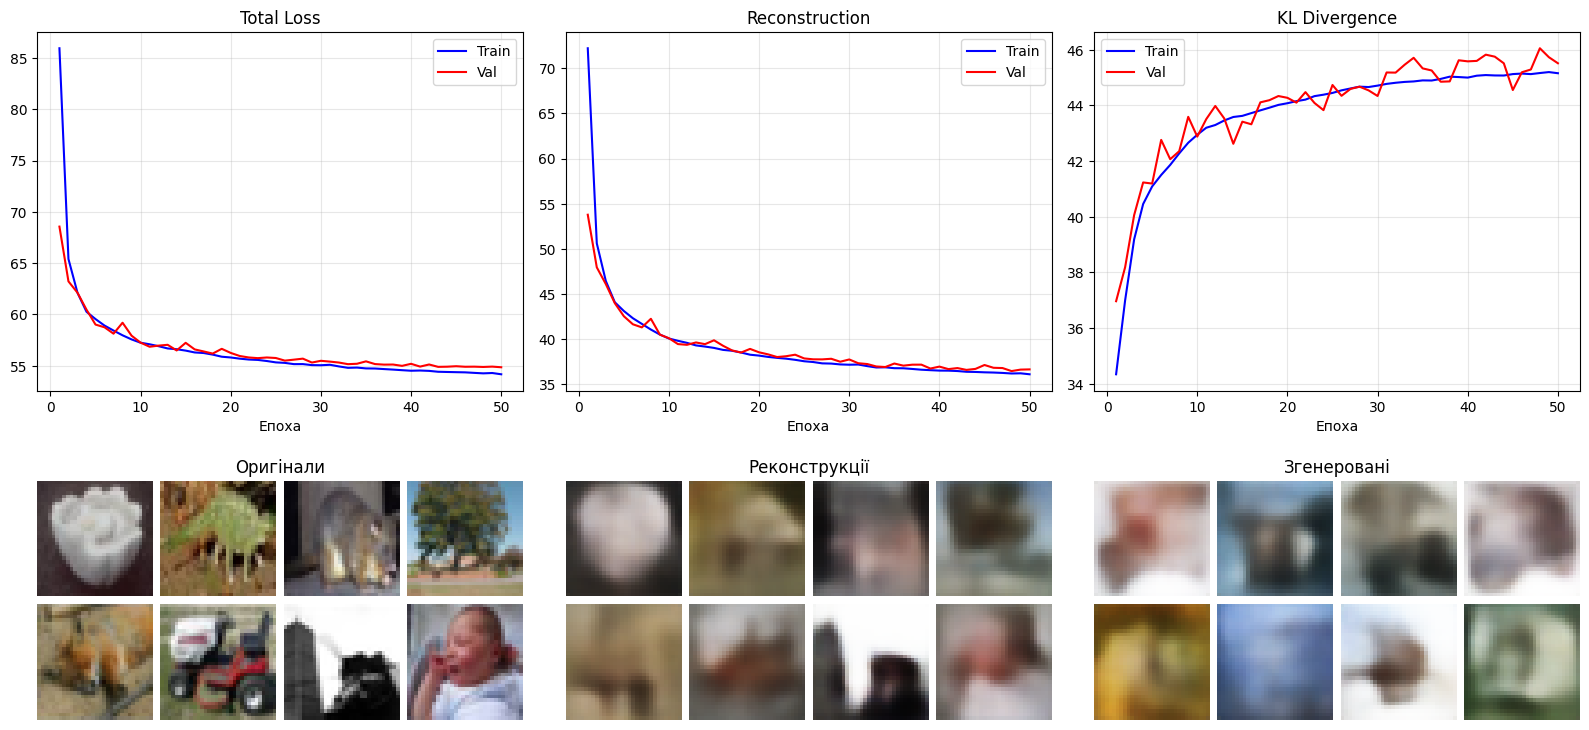

In [36]:
train_losses, val_losses = train_vae(
    model, train_loader, test_loader,
    epochs=NUM_EPOCHS, lr=LEARNING_RATE, beta=BETA,
    ckpt=checkpoint_mgr, resume=RESUME
)

### Інтерпретація результатів
---

Аналіз впливу параметра $\beta$ на навчання VAE. (Нагадаю, що $\beta$ — це вага KL Divergence у функції втрат). Важливість і факт його зміни я вже описував на початку. Протягом лабораторної я тричі запускав модель, але з різними параметрами. Результати в таблиці:

| Параметр                | β = 1.0 (30 епох) | β = 0.5 (50 епох) | β = 0.4 (50 епох) |
| ----------------------- | ----------------- | ----------------- | ----------------- |
| **Reconstruction Loss** | ~54               | ~40               | ~36               |
| **KL Divergence**       | ~22               | ~38               | ~44               |
| **Total Loss**          | ~75               | ~59               | ~55               |

Отже з експериментів можна бачити, що:

1. **Reconstruction Loss падає** при зменшенні β:

   - β=1.0: ~54
   - β=0.5: ~40 (↓26%)
   - β=0.4: ~36 (↓33% від початкового)

Низький $\beta$ забезпечує чіткіші реконструйованого зображенння, модель краще зберігатиме деталі, і буде нижчий total loss. Проте є і мінуси: латентний простір може стати менш регулярним, генерація зображення з випадкового z може бути гіршою та і інтерполяція може бути менш плавною. Для $\beta \geq 1$ маємо зворотню ситуацію. Для моєї ситуації (CIFAR-100, CPU) найкраще $\beta$ залежитиме від цілі:

| Мета                   | Рекомендований β |
| ---------------------- | ---------------- |
| Найкраща реконструкція | 0.3 - 0.5        |
| Баланс якості          | 0.5 - 0.7        |
| Найкраща генерація     | 0.8 - 1.0        |

2. **KL Divergence зростає** при зменшенні β:

   - β=1.0: ~22
   - β=0.5: ~38 (↑73%)
   - β=0.4: ~44 (↑100% від початкового) - Це очікувана ситуація, оскільки encoder "розуміє", що тепер KL штрафується слабше(внесок KL в total loss зменшується), і починає використовувати латентний простір вільніше, відхиляючись від розподілу N(0,1)

3. **Total Loss покращується**, бо виграш в реконструкції перевищує штраф від KL.

## 9. Відновлення роботи (додав з розрахунку, якщо не встигну довчити в разі відключень)

In [37]:
#checkpoint_mgr.list()

In [38]:
# model = VAE(LATENT_DIM)
# train_losses, val_losses = train_vae(model, train_loader, test_loader,
#     epochs=NUM_EPOCHS, lr=LEARNING_RATE, beta=BETA,
#     ckpt=checkpoint_mgr, resume='checkpoint_latest.pt')

## 10. Результати

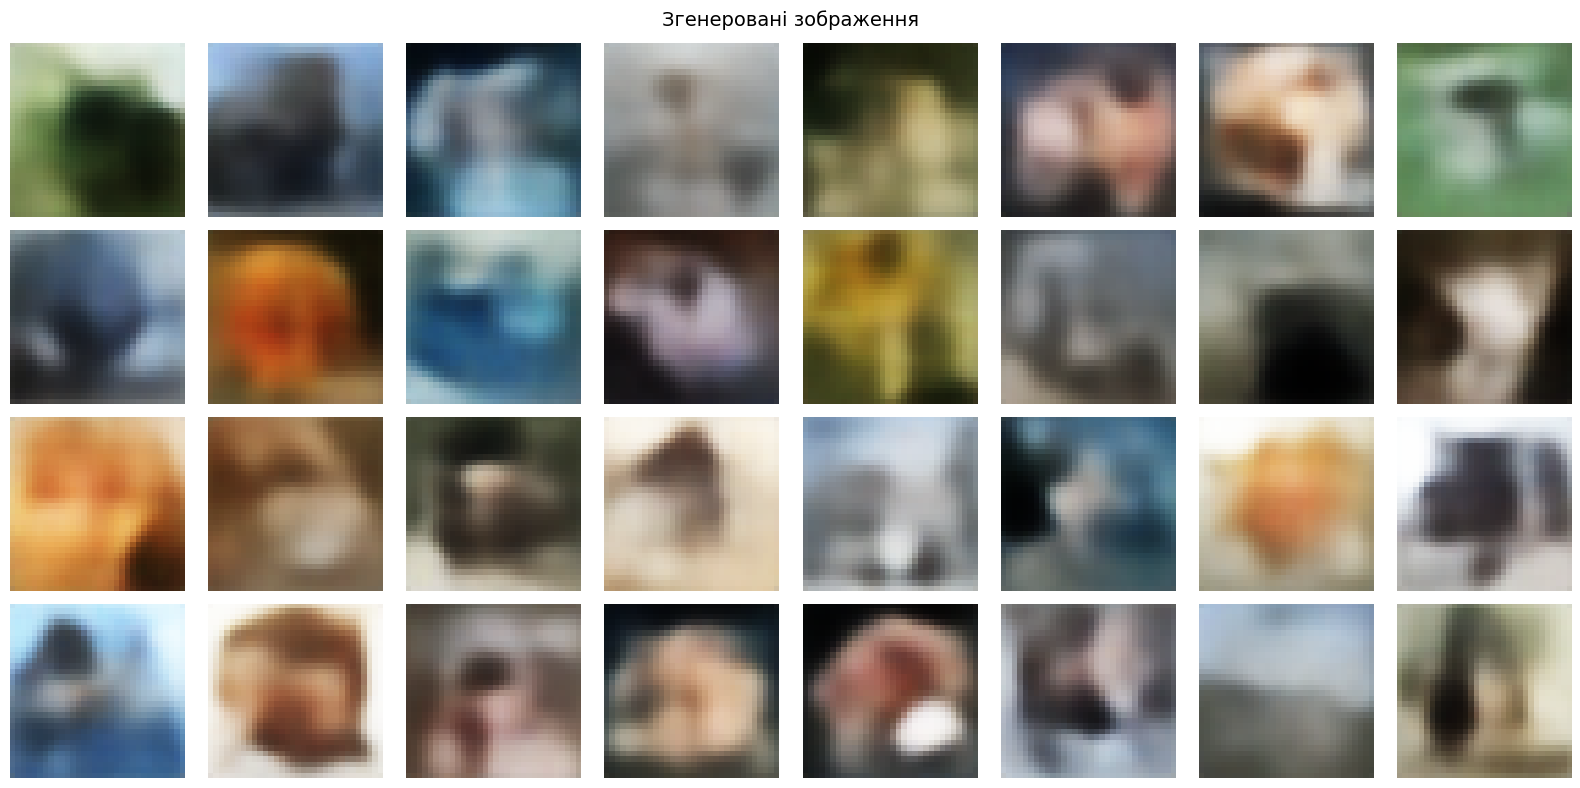

In [39]:
model.eval()
fig, axes = plt.subplots(4, 8, figsize=(16,8))
fig.suptitle('Згенеровані зображення', fontsize=14)
for ax, img in zip(axes.flat, model.generate(32)):
    ax.imshow(np.clip(img.permute(1,2,0).numpy(), 0, 1)); ax.axis('off')
plt.tight_layout(); plt.savefig('generated.png', dpi=150); plt.show()

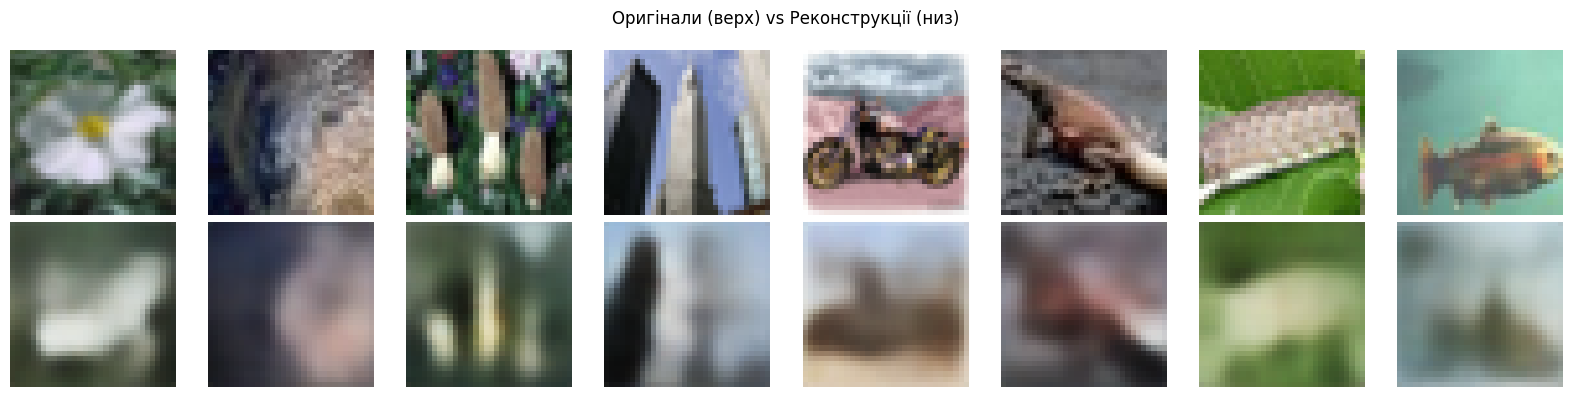

In [40]:
test_batch = next(iter(test_loader))[0][:8]
recon = model.reconstruct(test_batch)

fig, axes = plt.subplots(2, 8, figsize=(16,4))
fig.suptitle('Оригінали (верх) vs Реконструкції (низ)')
for i in range(8):
    axes[0,i].imshow(np.clip(test_batch[i].permute(1,2,0).numpy(),0,1)); axes[0,i].axis('off')
    axes[1,i].imshow(np.clip(recon[i].permute(1,2,0).numpy(),0,1)); axes[1,i].axis('off')
plt.tight_layout(); plt.savefig('reconstruction.png', dpi=150); plt.show()

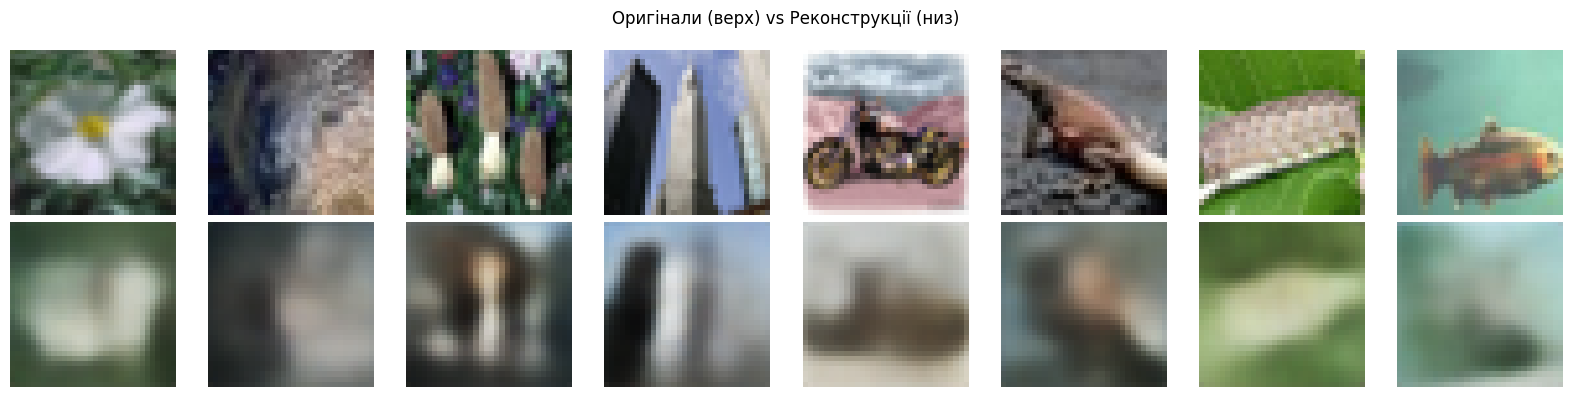

In [44]:
from IPython.display import Image
Image(filename='beta0.5.png')

В принципі, досягається навіть непогана візуальна якість - проглядаються силуети зображень. Можна бачити, що реконструкції непогано зберігають загальну композицію і кольори (квітка, skyscraper, мотокцикл, риба впізнаються при $\beta=0.5$ та при $\beta=0.4$). Згенеровані зображення типово розмиті для VAE, але мають реалістичні кольорові патерни і структури. Різниця в якості при близьких $\beta$ як можна бачити мінімальна.

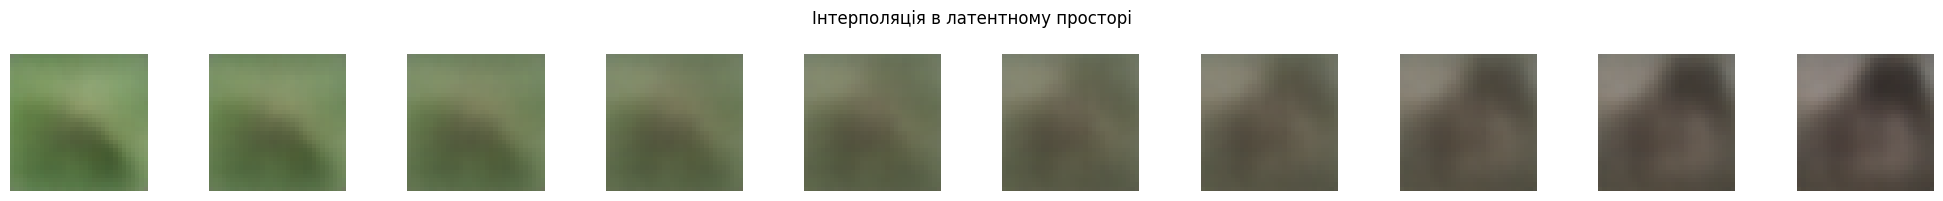

In [41]:
# Інтерполяція
imgs = next(iter(test_loader))[0]
with torch.no_grad():
    mu1, _ = model.encoder(imgs[0:1])
    mu2, _ = model.encoder(imgs[5:6])
    interp = [model.decoder((1-a)*mu1 + a*mu2)[0] for a in np.linspace(0,1,10)]

fig, axes = plt.subplots(1, 10, figsize=(20,2))
fig.suptitle('Інтерполяція в латентному просторі')
for ax, img in zip(axes, interp):
    ax.imshow(np.clip(img.permute(1,2,0).numpy(),0,1)); ax.axis('off')
plt.tight_layout(); plt.savefig('interpolation.png', dpi=150); plt.show()

Інтерполяція в латентному просторі - показує плавний перехід між двома обраними зображеннями.

Штучний приклад: Нехай обрали два якихось зображення, кодуємо їх в латентні вектори $z_1$ і $z_2$, і поступово "переходимо" (наприклад за 10 кроків) від одного до іншого.

Зображення A → Encoder → z₁ = [0.2, -0.5, 1.3, ...]  (128 чисел)

Зображення B → Encoder → z₂ = [0.8, 0.3, -0.7, ...]  (128 чисел)

- Крок 0:   z = z₁                    → Decoder → Картинка A
- Крок 1:   z = 0.9·z₁ + 0.1·z₂       → Decoder → Майже A
- Крок 5:   z = 0.5·z₁ + 0.5·z₂       → Decoder → Щось середнє
- Крок 9:   z = z₂                    → Decoder → Картинка B

Така ситуація, як в мене на картинці, демонструє що латентний простір є неперервним і між будь-якими двома точками можна плавно перейти та всі проміжні точки дають +- осмислені зображення. Це є ознакою того, що VAE навчився структурувати простір.

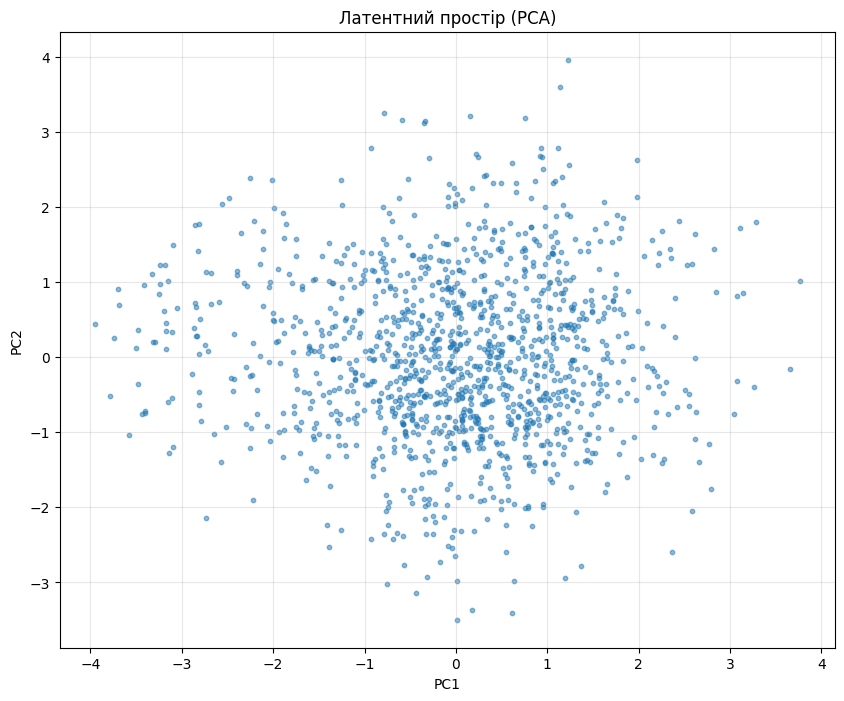

Пояснено: 7.0%


In [42]:
from sklearn.decomposition import PCA

latents = []
with torch.no_grad():
    for i, (x,) in enumerate(test_loader):
        if i >= 10: break
        latents.append(model.encoder(x)[0].numpy())
latents = np.concatenate(latents)

pca = PCA(2)
proj = pca.fit_transform(latents)

plt.figure(figsize=(10,8))
plt.scatter(proj[:,0], proj[:,1], alpha=0.5, s=10)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Латентний простір (PCA)')
plt.grid(alpha=0.3); plt.savefig('latent_pca.png', dpi=150); plt.show()
print(f"Пояснено: {sum(pca.explained_variance_ratio_)*100:.1f}%")

Оскільки алгоритм кожне зображення з тестового набору кодує в 128-вимірний вектор і всі 128 вимірів неможливо візуалізувати, то PCA стискає їх до 2 вимірів, зберігаючи максимум інформації. Ці 2 виміри зберегли лише 7% інформації. Решта 93% — у тих 126 вимірах, які були вимкнуті. _Це дуже навіть добре для нашої моделі VAE_. Якби було написано навпаки: "Пояснено 93%", це означало б, що модель реально використовує лише 2 виміри з 128, а решта є марними.

KL divergence змушує використовувати всі 128 вимірів рівномірним чином. Інформація розмазана по всьому простору, а не сконцентрована в кількох напрямках (немає "дірок"). І модель не колапсувала в кілька окремих кластерів (особливість VAE. Для кластерів, за потреби використовувати Conditional VAE). Розподіл схожий на 2D Гаусіан — трошки більше точок в центрі, менше на краях. Це саме те, чого хоче KL divergence: наблизити латентний розподіл до N(0, I) з можливістю подальшого семплювання випадкових z ~ N(0,1) для отримання реалістичних зображень.

### 11. Збереження кращої моделі

In [43]:
# Оця штука нікому не здалася, оскільки і вибірка маленька, і результати хотілося б кращі,
# але я по аналогії з першим завданням її зробив най буде)
torch.save({
    'model': model.state_dict(),
    'latent_dim': LATENT_DIM,
    'config': {'batch': BATCH_SIZE, 'lr': LEARNING_RATE, 'beta': BETA, 'epochs': NUM_EPOCHS}
}, 'vae_final.pt')
print(f"✅ Збережено: vae_final.pt ({os.path.getsize('vae_final.pt')/1024/1024:.2f} MB)")

✅ Збережено: vae_final.pt (5.65 MB)


## 12. Висновки

Протягом завдання я реалізовував **Variational Autoencoder (VAE)** для генерації зображень 32×32 RGB на датасеті CIFAR-100 (60,000 зображень, 100 класів). Всі проміжні висновки дублювати не буду, зазначу основне:

- Зменшення β покращує якість реконструкцій ціною менш регулярного латентного простору. Оптимальне значення для даної задачі: **β = 0.4–0.5**.
- Проведена **інтерполяція** підтвердила неперервність латентного простору — плавні переходи між зображеннями
- **PCA проекція** показала рівномірний розподіл (7% дисперсії у 2D), що свідчить про ефективне використання всіх 128 вимірів
- Модель зійшлася (converged) після ~35 епох
- Розмитість згенерованих зображень це фундаментальна властивість VAE з MSE loss, не є проблемою навчання. MSE усереднює можливі варіанти, що призводить до втрати деталей.

Покращення, які можливі:
- Використання **perceptual loss** замість MSE для чіткіших зображень
- Використання **Conditional VAE** замість **Variational Autoencoder (VAE)** для генерації зображень з конкретних класів
- Збільшення latent_dim або глибини мережі при наявності GPU